# Multimodality landscape features

Illustrates MOLA's **multimodality** landscape features (paper §4.1.2, Table 1). Each section pairs a feature's definition with a small, real, *executed* example built on `mola`'s own code.

Built incrementally — one section is added per feature, in the same commit that implements it (see `CLAUDE.md`'s "Feature implementation matrix"). As of this notebook: `plo_n`, `plo_dist_avg`, `plo_dist_max`, `nd_per_plo`.

## `plo_n`, `plo_dist_avg`, `plo_dist_max`, `nd_per_plo` — Pareto local optima

> "a Pareto local optimum (plo) [is a] sampled solution for which there does not exist any dominating neighbour" (§4.1.2)

Reuses `mola.dominance` — a solution is a PLO iff its `dominating` count is zero. This is a genuinely different set from the non-dominated front: a solution can be **globally dominated** yet still a PLO, if the specific neighbour(s) that would dominate it happen not to be among its `k` nearest. The two plots below make the difference visible on the same toy sample. `plo_dist_avg`/`plo_dist_max` are the average/maximum pairwise variable-space distance restricted to the PLO subset — same normalization convention as every other `*_AVG`/`*_MAX` distance feature. `nd_per_plo = nd_n / plo_n` (Table 1's own formula) is always ≤ 1, since every non-dominated solution is trivially also a PLO.

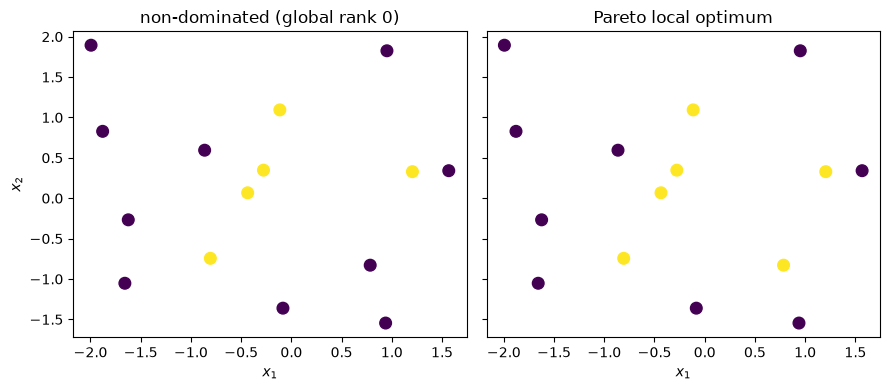

nd_n         = 0.333
plo_n        = 0.400
nd_per_plo   = 0.833


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mola.distance import build_neighbourhood
from mola.dominance import neighbourhood_dominance
from mola.features import nd_n, nd_per_plo, plo_dist_avg, plo_dist_max, plo_n
from mola.normalization import build_normalizers
from mola.ranking import rank_solutions

# Same toy bi-objective problem as the evolvability notebook: two spheres centred at
# (1, 1) and (-1, -1), so variable-space location has real structure in objective space.
mm_rng = np.random.default_rng(seed=3)
variables = mm_rng.uniform(low=-2.0, high=2.0, size=(15, 2))
objectives = np.column_stack(
    [
        ((variables - 1.0) ** 2).sum(axis=1),
        ((variables + 1.0) ** 2).sum(axis=1),
    ]
)

neighbourhood = build_neighbourhood(variables, neighbours=variables.shape[1])
ranking = rank_solutions(objectives)
dominance = neighbourhood_dominance(objectives, neighbourhood)
is_plo = dominance.dominating == 0

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
axes[0].scatter(variables[:, 0], variables[:, 1], c=(ranking.rank == 0), s=70)
axes[0].set_title("non-dominated (global rank 0)")
axes[1].scatter(variables[:, 0], variables[:, 1], c=is_plo, s=70)
axes[1].set_title("Pareto local optimum")
for ax in axes:
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
fig.tight_layout()
plt.show()

print(f"nd_n         = {nd_n(ranking):.3f}")
print(f"plo_n        = {plo_n(dominance):.3f}")
print(f"nd_per_plo   = {nd_per_plo(ranking, dominance):.3f}")

In [2]:
normalizer = build_normalizers(variables, objectives).variable_space

print(f"plo_dist_avg = {plo_dist_avg(variables, dominance, normalizer):.3f}")
print(f"plo_dist_max = {plo_dist_max(variables, dominance):.3f}")

plo_dist_avg = 0.260
plo_dist_max = 2.280
